# Метрики детекции: считаем mAP с нуля

Ноутбук к теме [`lesson.md`](lesson.md). «Реализуйте mAP» — частая задача на собеседовании, и почти все ошибаются в одном и том же месте: в правиле сопоставления и в том, что дубликат обязан стать FP.

1. IoU и сопоставление предсказаний с истиной
2. AP тремя способами — с проверкой на примере, посчитанном вручную
3. Порог NMS против mAP: почему пересуппрессия дороже недосуппрессии
4. Почему детекторы выдают сотню боксов на картинку

In [1]:
import numpy as np
import matplotlib.pyplot as plt

C_BG, C_INK, C_GRAY = "#faf9f5", "#141413", "#b0aea5"
C_PANEL, C_ORANGE, C_BLUE, C_GREEN = "#e8e6dc", "#d97757", "#6a9bcc", "#788c5d"
plt.rcParams.update({
    "figure.facecolor": C_BG, "axes.facecolor": C_BG, "axes.edgecolor": C_GRAY,
    "text.color": C_INK, "xtick.color": C_INK, "ytick.color": C_INK,
    "axes.labelcolor": C_INK, "font.size": 11, "legend.frameon": False,
})

def despine(ax):
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

## 1. IoU и сопоставление

Правило VOC/COCO: идём по предсказаниям **в порядке убывания уверенности**; каждое забирает самый перекрывающийся свободный истинный бокс. Занятый объект второй раз отдать нельзя — поэтому дубликат становится FP.

In [2]:
def iou(a, b):
    """IoU двух боксов (x1, y1, x2, y2)."""
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0.0, ix2 - ix1) * max(0.0, iy2 - iy1)
    ua = (a[2] - a[0]) * (a[3] - a[1]) + (b[2] - b[0]) * (b[3] - b[1]) - inter
    return inter / ua

def match_detections(preds, scores, gts, thr):
    """Возвращает флаги TP/FP по убыванию уверенности и число пропущенных объектов."""
    order = np.argsort(scores)[::-1]
    taken = [False] * len(gts)
    flags = []
    for i in order:
        best_j, best = -1, 0.0
        for j, g in enumerate(gts):
            v = iou(preds[i], g)
            if v > best:
                best, best_j = v, j
        if best >= thr and best_j >= 0 and not taken[best_j]:
            taken[best_j] = True
            flags.append(1)
        else:
            flags.append(0)
    return np.array(flags), int(sum(1 for t in taken if not t))

# дубликат обязан стать FP, даже если IoU высокий
gts = [(0, 0, 2, 2)]
preds = [(0.0, 0.0, 2.0, 2.0), (0.05, 0.05, 2.05, 2.05)]
f, fn = match_detections(preds, [0.9, 0.8], gts, 0.5)
print(f"IoU дубликата с объектом: {iou(preds[1], gts[0]):.2f}")
print(f"флаги: {f.tolist()}  → второй стал FP, хотя IoU выше порога")

IoU дубликата с объектом: 0.91
флаги: [1, 0]  → второй стал FP, хотя IoU выше порога


## 2. AP тремя способами

PR-кривая детектора пилообразна: каждое FP роняет precision, каждое TP поднимает. Поэтому перед интегрированием её заменяют **монотонной огибающей** — в каждой точке берут максимум precision справа.

In [3]:
def pr_curve(flags, n_gt):
    tp, fp = np.cumsum(flags), np.cumsum(1 - flags)
    return tp / np.maximum(tp + fp, 1e-12), tp / n_gt

def ap_all_point(precision, recall):
    """VOC2010+: точная площадь под огибающей."""
    mrec = np.concatenate([[0.0], recall, [1.0]])
    mpre = np.concatenate([[0.0], precision, [0.0]])
    for i in range(len(mpre) - 2, -1, -1):
        mpre[i] = max(mpre[i], mpre[i + 1])
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    return float(np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1]))

def ap_interp(precision, recall, n_points):
    """11 точек — VOC2007, 101 точка — COCO."""
    env = [float(precision[recall >= r].max()) if (recall >= r).any() else 0.0
           for r in np.linspace(0, 1, n_points)]
    return float(np.mean(env))

Прежде чем доверять реализации — проверим её на примере, который считается на бумаге. Три объекта, пять детекций, флаги `[1,0,1,1,0]`.

In [4]:
flags_demo, n_gt_demo = np.array([1, 0, 1, 1, 0]), 3
p_demo, r_demo = pr_curve(flags_demo, n_gt_demo)
print("precision:", np.round(p_demo, 4))
print("recall:   ", np.round(r_demo, 4))

got_all = ap_all_point(p_demo, r_demo)
got_11 = ap_interp(p_demo, r_demo, 11)
print(f"\nall-point AP = {got_all:.4f}   вручную 0.8333   {'✓' if abs(got_all - 0.8333) < 1e-3 else '✗'}")
print(f"11-point  AP = {got_11:.4f}   вручную 0.8409   {'✓' if abs(got_11 - 0.8409) < 1e-3 else '✗'}")

# граничные случаи
print("\nни одного TP:", ap_all_point(*pr_curve(np.array([0, 0, 0]), 2)))
print("всё найдено: ", ap_all_point(*pr_curve(np.array([1, 1]), 2)))

precision: [1.     0.5    0.6667 0.75   0.6   ]
recall:    [0.3333 0.3333 0.6667 1.     1.    ]

all-point AP = 0.8333   вручную 0.8333   ✓
11-point  AP = 0.8409   вручную 0.8409   ✓

ни одного TP: 0.0
всё найдено:  1.0


## 3. Порог NMS против mAP

Сырой выход детектора полон дубликатов. Учебник говорит, что у порога NMS две беды: слишком строгий удалит настоящие детекции соседних объектов, слишком мягкий оставит дубликаты, и каждый станет FP. Проверим, симметричны ли эти беды на самом деле.

Строим набор с дубликатами — имитацию выхода **до** NMS.

In [5]:
def make_raw_detections(seed=5, n_images=80):
    """Сырой выход детектора: у каждого объекта несколько перекрывающихся боксов."""
    rng = np.random.default_rng(seed)
    dataset = []
    for _ in range(n_images):
        gts = []
        for _ in range(rng.integers(1, 4)):
            x, y = rng.uniform(0.5, 5.5), rng.uniform(0.5, 5.5)
            gts.append((x, y, x + rng.uniform(1.8, 3.2), y + rng.uniform(1.8, 3.2)))
        preds, scores = [], []
        for g in gts:
            if rng.random() > 0.85:      # объект пропущен целиком
                continue
            for k in range(rng.integers(1, 5)):   # 1-4 дубликата на объект
                q = rng.beta(5, 2) * (0.85 ** k)
                sh = (1 - q) * 1.4
                dx, dy = rng.normal(0, sh, 2)
                preds.append((g[0] + dx, g[1] + dy, g[2] + dx, g[3] + dy))
                scores.append(float(np.clip(q * 0.9 + rng.normal(0, 0.05), 0.02, 0.99)))
        for _ in range(rng.poisson(1.0)):          # ложные срабатывания
            x, y = rng.uniform(0.5, 6.0), rng.uniform(0.5, 6.0)
            preds.append((x, y, x + rng.uniform(1.5, 3.0), y + rng.uniform(1.5, 3.0)))
            scores.append(float(np.clip(rng.beta(1.6, 4.0), 0.02, 0.99)))
        dataset.append((preds, scores, gts))
    return dataset

def nms(boxes, scores, thr):
    order = list(np.argsort(scores)[::-1])
    keep = []
    while order:
        best = order.pop(0)
        keep.append(best)
        order = [i for i in order if iou(boxes[best], boxes[i]) <= thr]
    return keep

def evaluate(dataset, iou_thrs=np.arange(0.5, 0.96, 0.05)):
    """AP по всему набору для каждого порога IoU; возвращает (AP@0.5, mAP@[.5:.95])."""
    aps = []
    for t in iou_thrs:
        flags_all, scores_all, n_gt = [], [], 0
        for preds, sc, gts in dataset:
            n_gt += len(gts)
            if not preds:
                continue
            f, _ = match_detections(preds, sc, gts, float(t))
            flags_all.extend(f.tolist())
            scores_all.extend([sc[i] for i in np.argsort(sc)[::-1]])
        s = np.array(scores_all); fl = np.array(flags_all)
        g = np.argsort(s)[::-1]
        p, r = pr_curve(fl[g], n_gt)
        aps.append(ap_interp(p, r, 101))
    return aps[0], float(np.mean(aps))

raw = make_raw_detections()
print(f"боксов до NMS: {sum(len(p) for p, _, _ in raw)}, истинных объектов: {sum(len(g) for _, _, g in raw)}")

боксов до NMS: 450, истинных объектов: 169


In [6]:
nms_thrs = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
rows = []
for t in nms_thrs:
    filtered = []
    n_boxes = 0
    for preds, sc, gts in raw:
        if preds:
            k = nms(preds, sc, t)
            filtered.append(([preds[i] for i in k], [sc[i] for i in k], gts))
            n_boxes += len(k)
        else:
            filtered.append((preds, sc, gts))
    ap50, coco = evaluate(filtered)
    rows.append((t, n_boxes, ap50, coco))

print(f"{'порог NMS':>10} {'боксов':>8} {'AP@0.50':>9} {'mAP@[.5:.95]':>13}")
for t, n, a, c in rows:
    print(f"{t:>10.1f} {n:>8} {a:>9.3f} {c:>13.3f}")

best = max(rows, key=lambda r: r[3])
print(f"\nлучший mAP при пороге NMS = {best[0]:.1f}")

 порог NMS   боксов   AP@0.50  mAP@[.5:.95]
       0.1      194     0.544         0.276
       0.2      227     0.585         0.289
       0.3      263     0.616         0.298
       0.4      301     0.623         0.300
       0.5      340     0.633         0.305
       0.6      372     0.639         0.309
       0.7      410     0.639         0.309
       0.8      438     0.622         0.308
       0.9      447     0.620         0.309
       1.0      450     0.620         0.309

лучший mAP при пороге NMS = 0.7


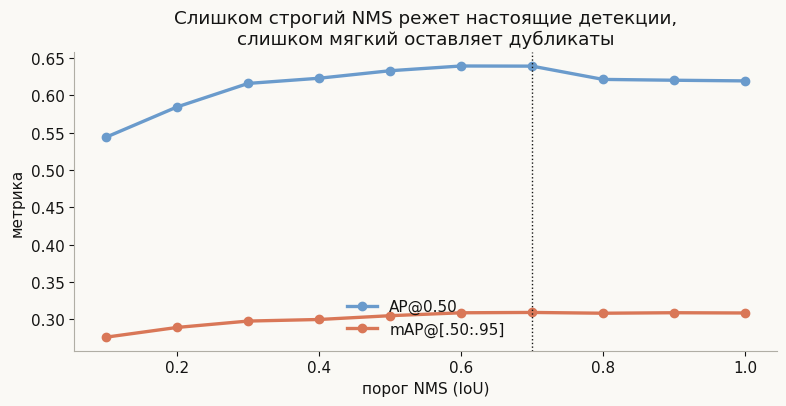

In [7]:
ts = [r[0] for r in rows]
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(ts, [r[2] for r in rows], "o-", color=C_BLUE, lw=2.4, label="AP@0.50")
ax.plot(ts, [r[3] for r in rows], "o-", color=C_ORANGE, lw=2.4, label="mAP@[.50:.95]")
ax.axvline(best[0], color=C_INK, lw=1.0, ls=":")
ax.set_xlabel("порог NMS (IoU)"); ax.set_ylabel("метрика")
ax.set_title("Слишком строгий NMS режет настоящие детекции,\nслишком мягкий оставляет дубликаты")
ax.legend(loc="lower center")
despine(ax); fig.tight_layout()

Беды оказались **несимметричны**. Строгий порог 0.1 роняет AP@0.50 с 0.639 до 0.544 — он выбрасывает настоящие детекции. А вот мягкий почти ничего не стоит: при пороге 1.0, то есть вообще **без подавления**, mAP@[.50:.95] равен 0.309 — ровно столько же, сколько в оптимуме.

Причина не в том, что дубликаты безвредны, а в том, что они **неуверенные**: после сортировки по confidence они оседают в хвосте PR-кривой, где precision уже низкая, и почти не отнимают площади. Метрика их едва замечает.

Практический вывод: если вы настраиваете порог NMS, ориентируясь только на mAP, вы почти не увидите разницы в широком диапазоне — и уйдёте в область, где на каждом изображении лежит гора лишних боксов. Следующий раздел показывает ту же ловушку в чистом виде.

## 4. Почему детекторы выдают сотню боксов на картинку

Контринтуитивный момент, который любят спрашивать: если добавить в выход кучу **неуверенных** предсказаний, mAP почти не пострадает и может даже вырасти. Причина в том, что AP интегрирует по всей PR-кривой: неуверенные боксы попадают в её хвост, где precision уже низкая, а любое случайное попадание добавляет recall.

Проверим: возьмём разумный порог NMS и будем отсекать предсказания по уверенности, глядя, что происходит с mAP и с precision на этом же пороге.

In [8]:
filtered = []
for preds, sc, gts in raw:
    if preds:
        k = nms(preds, sc, 0.5)
        filtered.append(([preds[i] for i in k], [sc[i] for i in k], gts))
    else:
        filtered.append((preds, sc, gts))

print(f"{'отсечка':>8} {'боксов':>8} {'mAP@[.5:.95]':>13} {'precision':>10} {'recall':>8}")
for cut in [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7]:
    kept, n_boxes = [], 0
    tp = fp = 0; n_gt = 0
    for preds, sc, gts in filtered:
        idx = [i for i, s in enumerate(sc) if s >= cut]
        p2 = [preds[i] for i in idx]; s2 = [sc[i] for i in idx]
        kept.append((p2, s2, gts)); n_boxes += len(p2); n_gt += len(gts)
        if p2:
            f, _ = match_detections(p2, s2, gts, 0.5)
            tp += int(f.sum()); fp += int((1 - f).sum())
    _, coco = evaluate(kept)
    prec = tp / max(tp + fp, 1)
    print(f"{cut:>8.2f} {n_boxes:>8} {coco:>13.3f} {prec:>10.3f} {tp / n_gt:>8.3f}")

 отсечка   боксов  mAP@[.5:.95]  precision   recall
    0.00      340         0.305      0.362    0.728
    0.05      338         0.305      0.364    0.728
    0.10      330         0.305      0.370    0.722
    0.20      312         0.305      0.391    0.722
    0.30      286         0.304      0.427    0.722
    0.50      176         0.292      0.619    0.645
    0.70       71         0.210      0.915    0.385


Отсечение неуверенных предсказаний **поднимает** precision в рабочей точке, но mAP при этом падает или стоит на месте. Отсюда два практических вывода:

- на лидерборде выгодно отдавать максимум боксов — mAP за это не наказывает;
- в продукте так делать нельзя: пользователь видит не площадь под кривой,   а одну рабочую точку, и там лишние боксы — это мусор на экране.

Расхождение между «метрикой соревнования» и «метрикой продукта» — ровно то, о чём стоит сказать вслух, если спросят, чем плох mAP.